```bash
=============================================================================
AIR QUALITY DATA IMPUTATION 
=============================================================================
 STRATEGY (in order of preference):
  Priority | Method                  | Trigger Condition
 ----------|-------------------------|--------------------------------------------
    1      | Forward-fill (ffill)    | Rainfall columns only (cumulative nature)
    2      | Circular interpolation  | Wind direction (0–360° wrap-around)
    3      | Linear interpolation    | Gaps < 6 hrs (24 x 15min steps)
    4      | 1-hour rolling median   | Short isolated gaps after linear fails
    5      | Same time previous day  | Gaps 6–48 hrs (captures daily cycles)
    6      | Same time previous week | Gaps 2–7 days (captures weekly cycles)
    7      | Monthly x Hour median   | Large/seasonal gaps
    8      | Column-wide median      | Last resort — should rarely fire
=============================================================================
```

In [41]:
# 1. Importing style libraries
import matplotlib.pyplot as plt
import scienceplots

# 2. Configuring matplotlib for IEEE publication style
plt.style.use(["science", "no-latex"])
plt.rcParams.update(
    {
        "font.family": "serif",
        "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
        "mathtext.fontset": "stix",
        "mathtext.default": "regular",
        "text.usetex": False,
        "font.size": 10,
        "axes.titlesize": 11,
        "axes.labelsize": 10,
        "xtick.labelsize": 9,
        "ytick.labelsize": 9,
        "legend.fontsize": 9,
        "figure.dpi": 150,
        "savefig.dpi": 300,
        "savefig.bbox": "tight",
        "savefig.pad_inches": 0.05,
        "axes.linewidth": 0.8,
        "lines.linewidth": 1.4,
        "xtick.direction": "in",
        "ytick.direction": "in",
    }
)

In [42]:
# ─────────────────────────────────────────────────────────────────────────────
# BLOCK 1 — CONFIGURATION (tune these without touching the logic below)
# What: Central place to change thresholds.
# Why:  Avoids magic numbers scattered through the code.
# Columns that are still too sparse after imputation — flag but keep
# ─────────────────────────────────────────────────────────────────────────────
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

SPARSE_THRESHOLD = 0.50  # if > 50 % missing after all steps, warn the user

# Paths
ROOT_DIR = Path().cwd().parents[2]
DATASET_DIR = ROOT_DIR / "backend" / "data"
ARTIFACTS_DIR = DATASET_DIR / "artifacts"
MASTER_PATH = ARTIFACTS_DIR / "master_dataset.csv"
IMPUTED_PATH = ARTIFACTS_DIR / "final_master_dataset.csv"
PLOTS_DIR = ARTIFACTS_DIR / "plots"
PLOTS_DIR.mkdir(parents=True, exist_ok=True)


In [43]:
# ─────────────────────────────────────────────────────────────────────────────
# BLOCK 2 — LOAD DATA & BASIC SANITY CHECKS
# What: Read the CSV and make sure time is parsed correctly.
# Why:  All time-based imputation breaks silently if "time" stays a string.
# ─────────────────────────────────────────────────────────────────────────────

master_df = pd.read_csv(MASTER_PATH)
master_df["time"] = pd.to_datetime(master_df["time"])
master_df = master_df.sort_values(["station_name", "time"]).reset_index(drop=True)

n_rows = len(master_df)
n_stations = master_df["station_name"].nunique()
date_min = master_df["time"].min()
date_max = master_df["time"].max()

print(f"Loaded {n_rows:,} rows | {n_stations} stations")
print(f"Date range: {date_min.date()} → {date_max.date()}")
print(f"Columns   : {list(master_df.columns)}")

Loaded 467,232 rows | 14 stations
Date range: 2025-01-01 → 2025-12-31
Columns   : ['time', 'pm25', 'pm10', 'no', 'no2', 'nox', 'nh3', 'so2', 'co', 'o3', 'benzene', 'toluene', 'xylene', 'o_xylene', 'ethyl_benzene', 'mp_xylene', 'average_temperature', 'relative_humidity', 'wind_speed', 'wind_direction', 'rainfall', 'total_rainfall', 'solar_radiation', 'pressure', 'vertical_wind_speed', 'station_name', 'site', 'org', 'latitude', 'longitude']


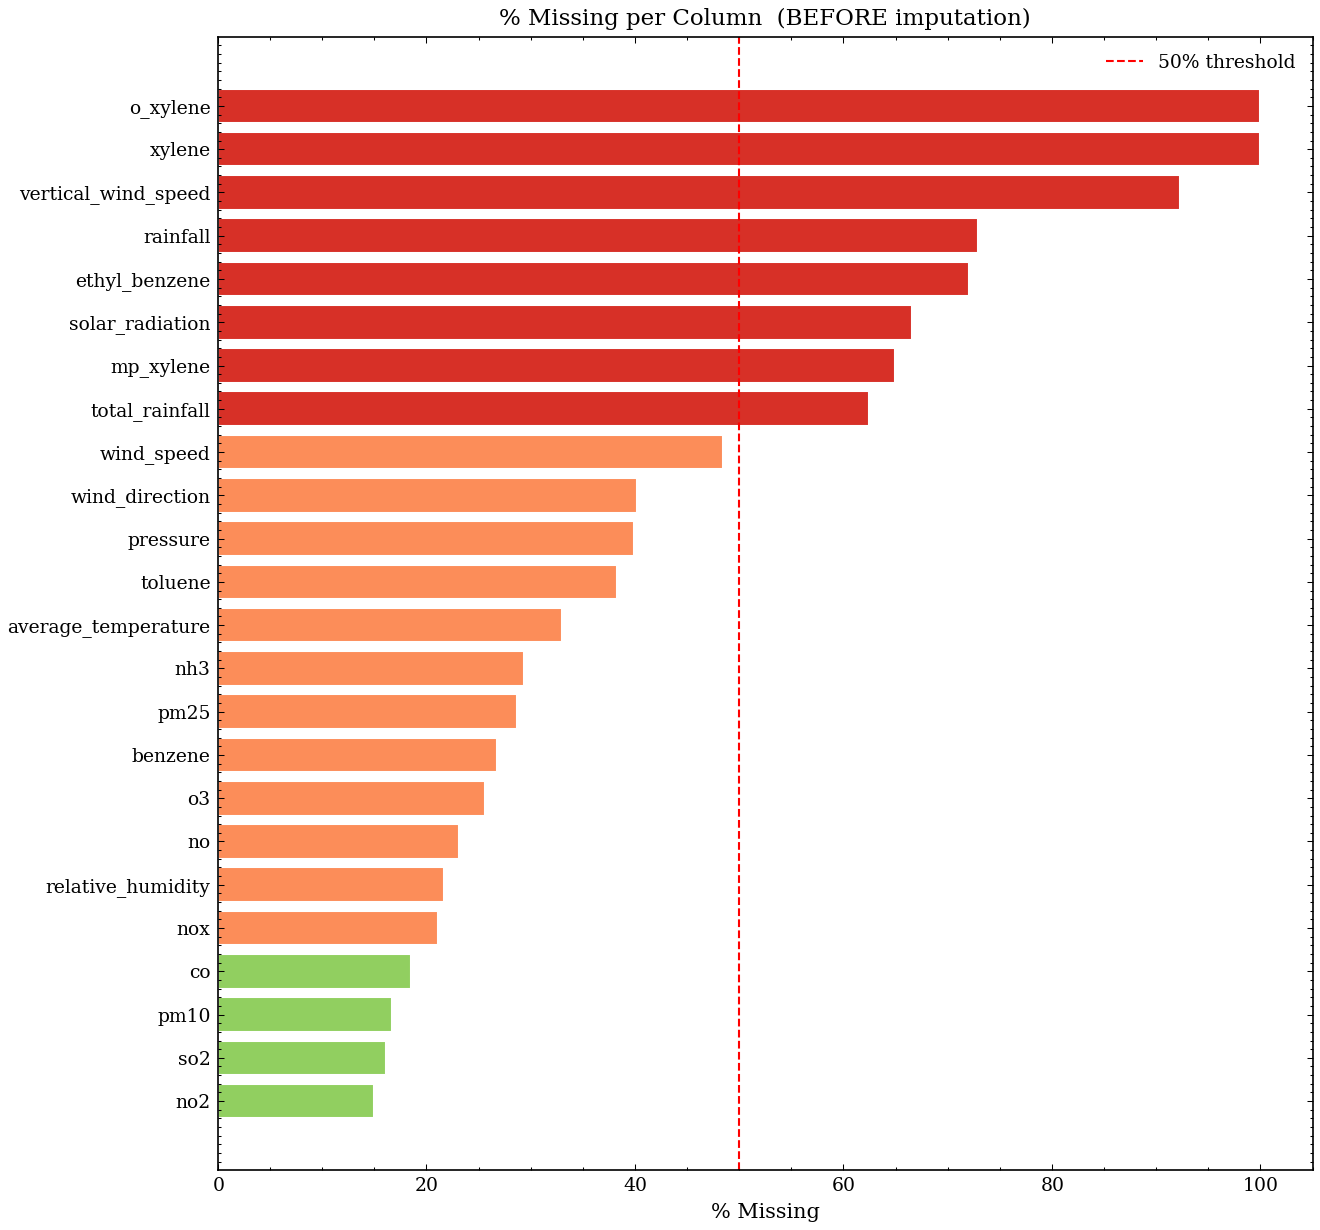

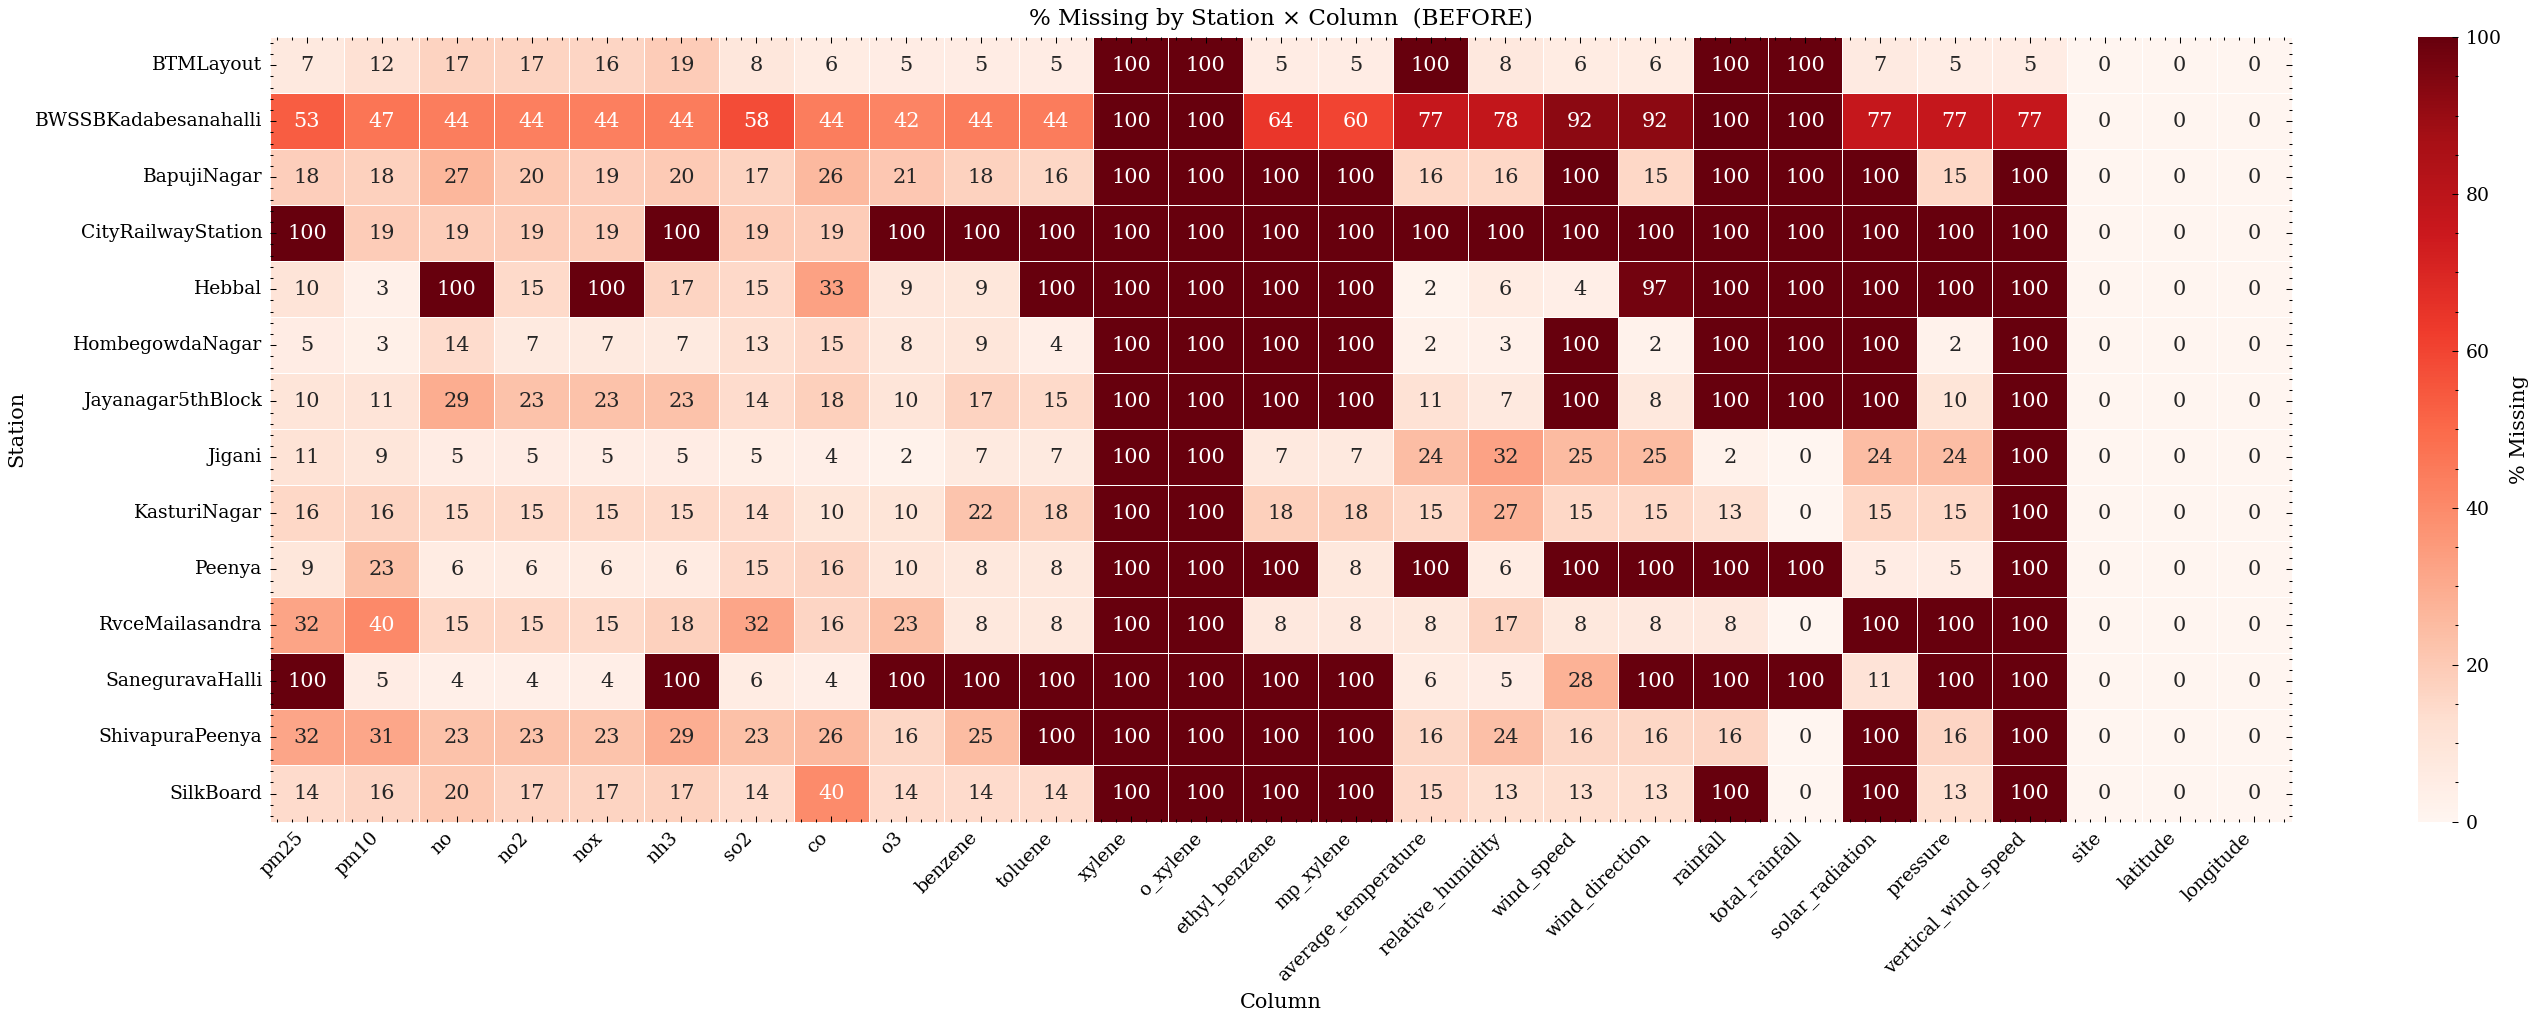

In [44]:
# ─────────────────────────────────────────────────────────────────────────────
# BLOCK 3 — VISUALISE MISSING DATA (BEFORE)
# What: Plot a heatmap of % missing per column and station.
# Why:  Seeing the pattern helps decide which columns to drop vs impute.
# ─────────────────────────────────────────────────────────────────────────────


def plot_missing_bar(df, title, save_name):
    """Horizontal bar chart: % missing per column, sorted descending."""
    miss = df.isnull().mean().sort_values(ascending=False) * 100
    miss = miss[miss > 0]
    if miss.empty:
        return
    colors = ["#d73027" if v > 50 else "#fc8d59" if v > 20 else "#91cf60" for v in miss]
    fig, ax = plt.subplots(figsize=(9, max(4, len(miss) * 0.35)))
    ax.barh(miss.index[::-1], miss.values[::-1], color=colors[::-1], edgecolor="white")
    ax.set_xlabel("% Missing")
    ax.set_title(title)
    ax.axvline(50, color="red", linestyle="--", linewidth=1, label="50% threshold")
    ax.legend()
    plt.tight_layout()
    fig.savefig(PLOTS_DIR / save_name)
    plt.show()


def plot_missing_heatmap(df, title, save_name):
    """Station × Column heatmap of % missing. Red = 100% missing."""
    numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
    pivot = df.groupby("station_name")[numeric_cols].apply(
        lambda g: g.isna().mean() * 100
    )
    fig, ax = plt.subplots(
        figsize=(max(14, len(numeric_cols) * 0.7), max(6, n_stations * 0.5))
    )
    sns.heatmap(
        pivot,
        ax=ax,
        cmap="Reds",
        vmin=0,
        vmax=100,
        linewidths=0.4,
        linecolor="white",
        annot=(pivot.shape[0] <= 20),
        fmt=".0f",
        cbar_kws={"label": "% Missing"},
    )
    ax.set_title(title)
    ax.set_xlabel("Column")
    ax.set_ylabel("Station")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    fig.savefig(PLOTS_DIR / save_name)
    plt.show()


# 8. Running the BEFORE plots
plot_missing_bar(
    master_df, "% Missing per Column  (BEFORE imputation)", "01_missing_before_bar.png"
)
plot_missing_heatmap(
    master_df,
    "% Missing by Station × Column  (BEFORE)",
    "02_missing_before_heatmap.png",
)

Block 4 — Dropping columns: ['o_xylene', 'xylene', 'vertical_wind_speed', 'ethyl_benzene', 'mp_xylene']
Remaining columns: ['time', 'pm25', 'pm10', 'no', 'no2', 'nox', 'nh3', 'so2', 'co', 'o3', 'benzene', 'toluene', 'average_temperature', 'relative_humidity', 'wind_speed', 'wind_direction', 'rainfall', 'total_rainfall', 'solar_radiation', 'pressure', 'station_name', 'site', 'org', 'latitude', 'longitude']


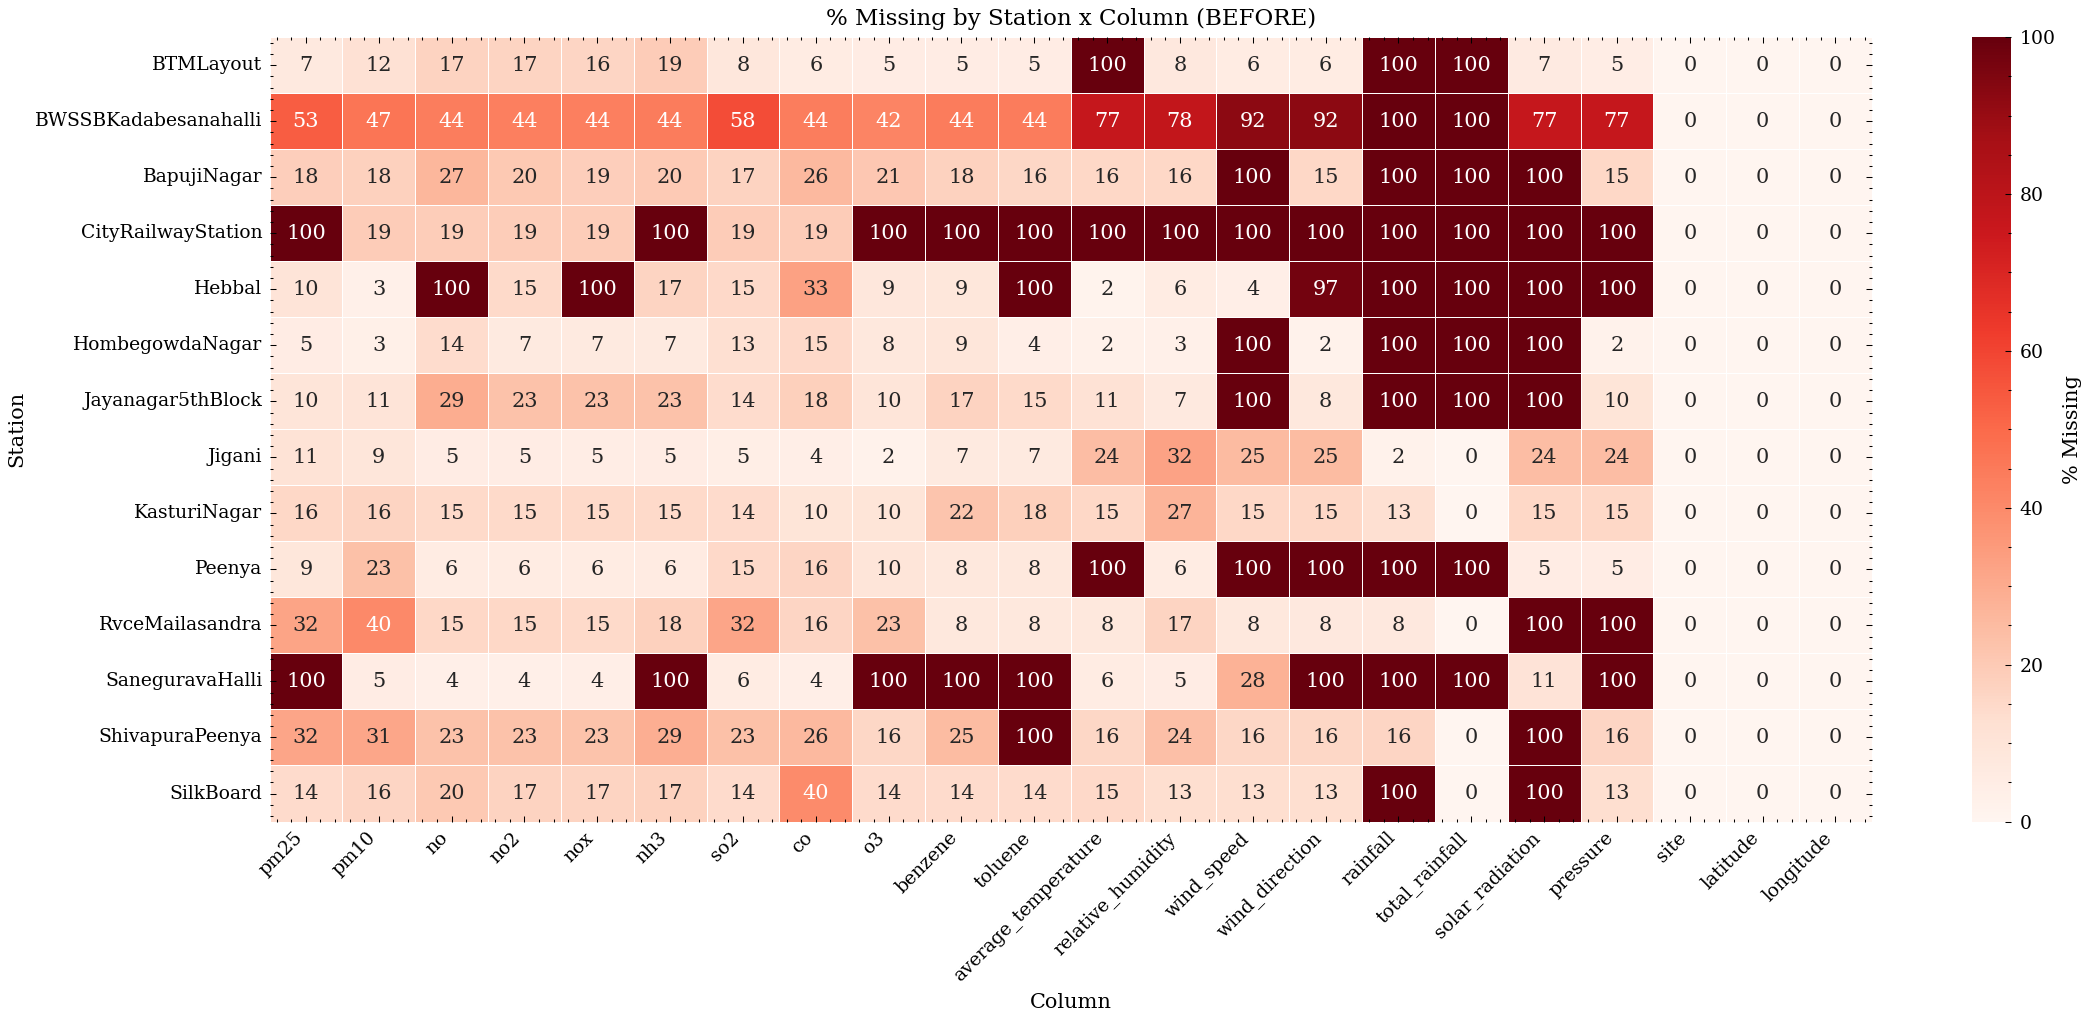

In [45]:
# ─────────────────────────────────────────────────────────────────────────────
# BLOCK 4 — DROP UNRECOVERABLE COLUMNS
# What: Remove columns that are ≥ 90 % missing across ALL stations.
# Why:  Imputing >90 % of a column manufactures data, not recovers it.
# ─────────────────────────────────────────────────────────────────────────────
# Columns to DROP before any imputation (>90 % missing → not recoverable)
DROP_COLS = ["o_xylene", "xylene", "vertical_wind_speed","ethyl_benzene","mp_xylene"]
print(f"Block 4 — Dropping columns: {DROP_COLS}")
master_df = master_df.drop(columns=[c for c in DROP_COLS if c in master_df.columns])
print(f"Remaining columns: {list(master_df.columns)}")
plot_missing_heatmap(
    master_df, "% Missing by Station x Column (BEFORE)", "02_missing_before_heatmap.png"
)

In [46]:
# ─────────────────────────────────────────────────────────────────────────────
# BLOCK 5 — HELPER FUNCTIONS
# What: Reusable functions that the main loop will call.
# Why:  Keeps the main loop clean and easy to read.
# ─────────────────────────────────────────────────────────────────────────────


def circular_interpolate(series: pd.Series) -> pd.Series:
    """
    Interpolate wind direction correctly across the 0–360° boundary.
    Naive linear interpolation on angles gives wrong results near 0/360.
    For example, midpoint between 350° and 10° should be 0°, not 180°.
    Fix: convert to sin/cos (cartesian), interpolate those, convert back.
    """
    rad = np.radians(series)
    sin_i = np.sin(rad).interpolate(method="linear", limit_direction="both")
    cos_i = np.cos(rad).interpolate(method="linear", limit_direction="both")
    return pd.Series(
        np.degrees(np.arctan2(sin_i, cos_i)) % 360,
        index=series.index,
    )


def count_remaining(df, cols):
    """Return total NaN count across given columns."""
    return df[cols].isna().sum().sum()

In [47]:
# ─────────────────────────────────────────────────────────────────────────────
# BLOCK 5.5 — GLOBAL TIMELINE SYNCHRONIZATION
# What: Expand every station's dataframe to span a strict global timeline
#       (Jan 1, 2025 00:00 to Dec 31, 2025 23:45) at 15-minute intervals.
# Why:  Ensures that early timeline gaps (like BWSSB starting in September)
#       are explicitly represented as rows of NaNs in long-format before pivoting.
# ─────────────────────────────────────────────────────────────────────────────
# ─────────────────────────────────────────────────────────────────────────────
# BLOCK 5.5 — GLOBAL TIMELINE SYNCHRONIZATION (STATION METADATA PRESERVED)
# ─────────────────────────────────────────────────────────────────────────────

print("Synchronizing all stations to a strict full-year calendar grid...")

# 1. Define the uniform global full-year timeline
start_time = "2025-01-01 00:00:00"
end_time = "2025-12-31 23:45:00"
full_year_index = pd.date_range(start=start_time, end=end_time, freq="15min")
synchronized_dfs = []

# 2. Identify your structural station details columns
station_meta_cols = ["station_name", "org", "site", "latitude", "longitude"]
# Ensure we only track columns that actually exist in your master_df
station_meta_cols = [c for c in station_meta_cols if c in master_df.columns]

ACTIVE_STATIONS = master_df["station_name"].unique()

for station in ACTIVE_STATIONS:
    # Isolate this station's data
    st_df = master_df[master_df["station_name"] == station].copy()
    
    # 3. Capture the static station details before reindexing
    # We grab the first valid row to get the correct org, site, lat, and lon mapping
    metadata_row = st_df[station_meta_cols].drop_duplicates().dropna(subset=["station_name"]).iloc[0]
    
    # Set time index and clean duplicates
    st_df = st_df.set_index("time").sort_index()
    st_df = st_df[~st_df.index.duplicated(keep="first")]

    # 4. Reindex to full calendar timeline
    # This automatically makes all pollutants, weather metrics, and metadata NaN for new rows
    st_df = st_df.reindex(full_year_index)
    st_df.index.name = "time"
    
    # 5. Overwrite only the station details using our saved metadata lookup
    # This leaves pollutants, wind_speed, solar_radiation, etc., as pure NaN
    for col in station_meta_cols:
        st_df[col] = metadata_row[col]

    synchronized_dfs.append(st_df.reset_index())

# 6. Reconstruct the global master_df
master_df = pd.concat(synchronized_dfs, ignore_index=True)
master_df = master_df.sort_values(["time", "station_name"]).reset_index(drop=True)

print("Grid synchronization complete!")
print(f"Total rows now in master_df: {len(master_df):,} ({len(ACTIVE_STATIONS)} stations × {len(full_year_index):,} steps)")

Synchronizing all stations to a strict full-year calendar grid...
Grid synchronization complete!
Total rows now in master_df: 490,560 (14 stations × 35,040 steps)


In [48]:
# ─────────────────────────────────────────────────────────────────────────────
# BLOCK 6 — OPTIMIZED MONTHLY-AWARE IMPUTATION LOOP (per station, per month)
# What: Apply cascading time-series imputation methods independently within
#       each valid calendar month slice for localized air quality tracking.
# Why:  Prevents lookback loops from executing over unbuilt/offline seasons,
#       eliminating processing lag and halting unscientific cross-seasonal bleeding.
# ─────────────────────────────────────────────────────────────────────────────

# ANSI Terminal Color Palette for Rich Logging
BLUE = "\033[34m"
GREEN = "\033[32m"
YELLOW = "\033[33m"
RESET = "\033[0m"

imputation_log = []  # Global register tracking every individual imputation action
all_imputed = []  # Master collection array for the fully processed station dataframes

STATION_NAMES = master_df["station_name"].unique()
CIRCULAR_COLS = ["wind_direction"]  # Angular metrics — require circular trigonometry
FFILL_COLS = [
    "rainfall",
    "total_rainfall",
]  # Cumulative tracking — require forward-carry physics

# Gap threshold configuration limits (measured in discrete 15-minute intervals)
MAX_LINEAR_STEPS = (
    24  # 24 intervals × 15 mins = Strict 6-hour ceiling for linear interpolation
)
MAX_ROLLING_STEPS = (
    4  # 4 intervals × 15 mins = Strict 1-hour window for local noise filtering
)

for station in tqdm(STATION_NAMES, desc="Imputing stations"):
    print(f"\nProcessing station: {station}")
    st_df = master_df[master_df["station_name"] == station].copy()

    # Identify structural system dead-zones: check which columns are 100% missing for the entire year
    numeric_cols = st_df.select_dtypes(include=np.number).columns.tolist()
    globally_dead_cols = [c for c in numeric_cols if st_df[c].isna().all()]

    # Initialize a localized dictionary to track real-time imputation progress for this station
    station_totals = {
        "Step 1 — FFill Rainfall": 0,
        "Step 2 — Circular Wind": 0,
        "Step 3 — Linear Interp": 0,
        "Step 4 — Rolling Median": 0,
        "Step 5 — Previous Day": 0,
        "Step 6 — Previous Week": 0,
        "Step 7 — Month Hour Med": 0,
        "Step 8 — Monthly Median": 0,
    }

    station_monthly_pieces = []
    month_groups = st_df.groupby(st_df["time"].dt.month)

    # ── MONTHLY GRANULARITY LOOP ─────────────────────────────────────────────
    # We break the year down into months to prevent lookbacks from bleeding across
    # macroscopic seasonal changes (e.g., using monsoon trends to fill summer gaps).
    # ─────────────────────────────────────────────────────────────────────────
    for month_val, month_df in month_groups:
        month_df = month_df.set_index("time").sort_index()

        # Calculate availability map to verify if the station was active during this month
        total_numeric_nulls = month_df[numeric_cols].isna().sum().sum()
        total_possible_cells = month_df[numeric_cols].size

        if total_numeric_nulls == total_possible_cells:
            # STRICT BYPASS: The station was entirely offline/unbuilt during this month.
            # Bypassing prevents infinite lookback loops and preserves pure structural NaNs.
            print(
                f"   [SKIP MONTH] Month {month_val:02d} is 100% empty. Preserving NaNs."
            )
            station_monthly_pieces.append(month_df.reset_index())
            continue

        # Non-numeric metadata columns (like site, org) cannot interpolate.
        # Forward-fill and backward-fill to ensure tracking metadata lines match index rows.
        meta_cols = month_df.select_dtypes(exclude=np.number).columns.tolist()
        month_df[meta_cols] = month_df[meta_cols].ffill().bfill()

        # ────────────────────────────────────────────────────────────────────
        # STEP 1 — Forward-fill for cumulative rainfall
        # Why: Rainfall is an accumulation; the last valid reading carries forward.
        # We fill 0 only if NO reading exists at all.
        # Time  | Raw Data | After .ffill()           | After .fillna(0) (Final)
        # 00:00 | NaN      | NaN (No previous value!) | 0.0 (Caught by fillna)
        # 00:15 | 1.2      | 1.2                      | 1.2
        # 00:30 | NaN      | 1.2 (Copied from 00:15)  | 1.2
        # 00:45 | 1.5      | 1.5                      | 1.5
        # ────────────────────────────────────────────────────────────────────
        for col in FFILL_COLS:
            if col in month_df.columns:
                before = month_df[col].isna().sum()
                month_df[col] = month_df[col].ffill().fillna(0)
                filled = before - month_df[col].isna().sum()
                if filled:
                    imputation_log.append(
                        dict(station=station, col=col, method="ffill", n_filled=filled)
                    )
                    station_totals["Step 1 — FFill Rainfall"] += filled

        # ────────────────────────────────────────────────────────────────────
        # STEP 2 — Circular interpolation for wind direction
        # Why: Wind direction wraps around a 360-degree modulus framework.
        #      Standard linear averages completely fail here (e.g., avg of 350° and 10° is 180° instead of 0°).
        # ────────────────────────────────────────────────────────────────────
        for col in CIRCULAR_COLS:
            if (
                col in month_df.columns
                and col not in globally_dead_cols
                and month_df[col].isna().sum() > 0
            ):
                before = month_df[col].isna().sum()
                month_df[col] = circular_interpolate(month_df[col])
                filled = before - month_df[col].isna().sum()
                if filled:
                    imputation_log.append(
                        dict(
                            station=station,
                            col=col,
                            method="circular_interp",
                            n_filled=filled,
                        )
                    )
                    station_totals["Step 2 — Circular Wind"] += filled

        # ────────────────────────────────────────────────────────────────────
        # STEP 3 — Linear interpolation (gaps ≤ 6 hours = 24 steps)
        # Why: For short micro-gaps, adjacent sensor readings provide a smooth,
        #      physically continuous, and highly meaningful local estimate.
        # ────────────────────────────────────────────────────────────────────
        remaining_cols = [
            c
            for c in numeric_cols
            if c not in FFILL_COLS + CIRCULAR_COLS and c not in globally_dead_cols
        ]
        for col in remaining_cols:
            if month_df[col].isna().sum() == 0:
                continue
            before = month_df[col].isna().sum()
            month_df[col] = month_df[col].interpolate(
                method="linear", limit=MAX_LINEAR_STEPS
            )
            filled = before - month_df[col].isna().sum()
            if filled:
                imputation_log.append(
                    dict(
                        station=station,
                        col=col,
                        method="linear_interp",
                        n_filled=filled,
                    )
                )
                station_totals["Step 3 — Linear Interp"] += filled

        # ────────────────────────────────────────────────────────────────────
        # STEP 4 — 1-hour rolling median (isolated spikes still missing)
        # Why: Single orphan points remain after linear steps if they sit directly
        #      at the edge of a massive drop-out zone. A local 1-hour window resolves them.
        # ────────────────────────────────────────────────────────────────────
        for col in remaining_cols:
            if month_df[col].isna().sum() == 0:
                continue
            rolling_med = (
                month_df[col].rolling(window=MAX_ROLLING_STEPS, min_periods=1).median()
            )
            missing_mask = month_df[col].isna()
            month_df.loc[missing_mask, col] = rolling_med[missing_mask]
            filled = missing_mask.sum() - month_df[col].isna().sum()
            if filled:
                imputation_log.append(
                    dict(
                        station=station,
                        col=col,
                        method="rolling_1h_median",
                        n_filled=filled,
                    )
                )
                station_totals["Step 4 — Rolling Median"] += filled

        # ────────────────────────────────────────────────────────────────────
        # STEP 5 — Same time, previous day (gaps 6–48 hours)
        # Why: Air pollution follows a strict diurnal rhythm based on rush-hour
        #      traffic waves and boundary layer mixing heights. Yesterday is an excellent baseline.
        # ────────────────────────────────────────────────────────────────────
        for col in remaining_cols:
            if month_df[col].isna().sum() == 0:
                continue
            n_filled = 0
            for idx in month_df[month_df[col].isna()].index:
                prev = idx - pd.Timedelta(days=1)
                if prev in month_df.index and pd.notna(month_df.loc[prev, col]):
                    month_df.loc[idx, col] = month_df.loc[prev, col]
                    n_filled += 1
            if n_filled:
                imputation_log.append(
                    dict(station=station, col=col, method="prev_day", n_filled=n_filled)
                )
                station_totals["Step 5 — Previous Day"] += n_filled

        # ────────────────────────────────────────────────────────────────────
        # STEP 6 — Same time, previous week (gaps 2–7 days)
        # Why: Models socio-economic weekly patterns (e.g., lower industrial emissions
        #      and reduced traffic volumes on weekends vs weekdays).
        # ────────────────────────────────────────────────────────────────────
        for col in remaining_cols:
            if month_df[col].isna().sum() == 0:
                continue
            n_filled = 0
            for idx in month_df[month_df[col].isna()].index:
                prev = idx - pd.Timedelta(days=7)
                if prev in month_df.index and pd.notna(month_df.loc[prev, col]):
                    month_df.loc[idx, col] = month_df.loc[prev, col]
                    n_filled += 1
            if n_filled:
                imputation_log.append(
                    dict(
                        station=station, col=col, method="prev_week", n_filled=n_filled
                    )
                )
                station_totals["Step 6 — Previous Week"] += n_filled

        # ────────────────────────────────────────────────────────────────────
        # STEP 7 — Hour of Day median (Localized strictly inside this month)
        # Why: Captures the stable profile for that hour within the current season
        #      (e.g., tracking late afternoon ozone generation profiles).
        # ────────────────────────────────────────────────────────────────────
        for col in remaining_cols:
            if month_df[col].isna().sum() == 0:
                continue
            medians = month_df.groupby(month_df.index.hour)[col].median()
            n_filled = 0
            for idx in month_df[month_df[col].isna()].index:
                key = idx.hour
                if key in medians.index and pd.notna(medians[key]):
                    month_df.loc[idx, col] = medians[key]
                    n_filled += 1
            if n_filled:
                imputation_log.append(
                    dict(
                        station=station,
                        col=col,
                        method="month_hour_median",
                        n_filled=n_filled,
                    )
                )
                station_totals["Step 7 — Month Hour Med"] += n_filled

        # ────────────────────────────────────────────────────────────────────
        # STEP 8 — Month-specific Column median fallback (Last resort)
        # Why: If a station undergoes a severe multi-week sensor failure, we
        #      stabilize the channel using a flat monthly-specific benchmark.
        # ────────────────────────────────────────────────────────────────────
        for col in remaining_cols:
            n = month_df[col].isna().sum()
            if n == 0:
                continue
            median_val = month_df[col].median()
            if pd.notna(median_val):
                month_df[col] = month_df[col].fillna(median_val)
                imputation_log.append(
                    dict(station=station, col=col, method="col_median", n_filled=n)
                )
                station_totals["Step 8 — Monthly Median"] += n

        station_monthly_pieces.append(month_df.reset_index())

    # Reassemble all 12 processed monthly data slices back together for the station
    station_df = pd.concat(station_monthly_pieces, ignore_index=True)
    print(f"{BLUE}📊 Imputation Summary for {station}:{RESET}")
    for step_name, count in station_totals.items():
        if count > 0:
            print(f"{BLUE}   ➔ {step_name:<25}: {count:,} values imputed{RESET}")

    # Final data architecture verify: Check for completely unresolvable channels
    for col in globally_dead_cols:
        print(
            f"{YELLOW}[SKIP ALL YEAR] {station} | {col}: 100% missing. Kept as NaN.{RESET}"
        )

    all_imputed.append(station_df)

# Overwrite master dataset with completely processed values
master_df = (
    pd.concat(all_imputed, ignore_index=True)
    .sort_values(["time", "station_name"])
    .reset_index(drop=True)
)

total_imputed_cells = sum(log["n_filled"] for log in imputation_log)
print(f"{GREEN}🎉 IMPUTATION PROCESSING COMPLETE!{RESET}")
print(f"{GREEN} Total cells recovered = {total_imputed_cells:,}{RESET}")

Imputing stations:   0%|          | 0/14 [00:00<?, ?it/s]


Processing station: BTMLayout


Imputing stations:   7%|▋         | 1/14 [00:04<01:04,  4.96s/it]

📊 Imputation Summary for BTMLayout:
   ➔ Step 1 — FFill Rainfall  : 70,080 values imputed
   ➔ Step 2 — Circular Wind   : 1,937 values imputed
   ➔ Step 3 — Linear Interp   : 22,464 values imputed
   ➔ Step 4 — Rolling Median  : 841 values imputed
   ➔ Step 5 — Previous Day    : 25,451 values imputed
   ➔ Step 7 — Month Hour Med  : 1,278 values imputed
[SKIP ALL YEAR] BTMLayout | average_temperature: 100% missing. Kept as NaN.
[SKIP ALL YEAR] BTMLayout | rainfall: 100% missing. Kept as NaN.
[SKIP ALL YEAR] BTMLayout | total_rainfall: 100% missing. Kept as NaN.

Processing station: BWSSBKadabesanahalli


Imputing stations:  14%|█▍        | 2/14 [00:42<04:50, 24.18s/it]

...

📊 Imputation Summary for SaneguravaHalli:
   ➔ Step 1 — FFill Rainfall  : 70,080 values imputed
   ➔ Step 3 — Linear Interp   : 14,245 values imputed
   ➔ Step 4 — Rolling Median  : 703 values imputed
   ➔ Step 5 — Previous Day    : 11,334 values imputed
   ➔ Step 7 — Month Hour Med  : 283 values imputed
[SKIP ALL YEAR] SaneguravaHalli | pm25: 100% missing. Kept as NaN.
[SKIP ALL YEAR] SaneguravaHalli | nh3: 100% missing. Kept as NaN.
[SKIP ALL YEAR] SaneguravaHalli | o3: 100% missing. Kept as NaN.
[SKIP ALL YEAR] SaneguravaHalli | benzene: 100% missing. Kept as NaN.
[SKIP ALL YEAR] SaneguravaHalli | toluene: 100% missing. Kept as NaN.
[SKIP ALL YEAR] SaneguravaHalli | wind_direction: 100% missing. Kept as NaN.
[SKIP ALL YEAR] SaneguravaHalli | rainfall: 100% missing. Kept as NaN.
[SKIP ALL YEAR] SaneguravaHalli | total_rainfall: 100% missing. Kept as NaN.
[SKIP ALL YEAR] SaneguravaHalli | pressure: 100% missing. Kept as NaN.

Processing station: ShivapuraPeenya


Imputing stations:  93%|█████████▎| 13/14 [01:59<00:08,  8.74s/it]

📊 Imputation Summary for ShivapuraPeenya:
   ➔ Step 1 — FFill Rainfall  : 5,653 values imputed
   ➔ Step 2 — Circular Wind   : 5,543 values imputed
   ➔ Step 3 — Linear Interp   : 25,629 values imputed
   ➔ Step 4 — Rolling Median  : 1,461 values imputed
   ➔ Step 5 — Previous Day    : 61,428 values imputed
   ➔ Step 7 — Month Hour Med  : 21,461 values imputed
[SKIP ALL YEAR] ShivapuraPeenya | toluene: 100% missing. Kept as NaN.
[SKIP ALL YEAR] ShivapuraPeenya | solar_radiation: 100% missing. Kept as NaN.

Processing station: SilkBoard


Imputing stations: 100%|██████████| 14/14 [02:04<00:00,  8.91s/it]

📊 Imputation Summary for SilkBoard:
   ➔ Step 1 — FFill Rainfall  : 35,040 values imputed
   ➔ Step 2 — Circular Wind   : 4,540 values imputed
   ➔ Step 3 — Linear Interp   : 59,129 values imputed
   ➔ Step 4 — Rolling Median  : 3,017 values imputed
   ➔ Step 5 — Previous Day    : 26,043 values imputed
   ➔ Step 7 — Month Hour Med  : 400 values imputed
[SKIP ALL YEAR] SilkBoard | rainfall: 100% missing. Kept as NaN.
[SKIP ALL YEAR] SilkBoard | solar_radiation: 100% missing. Kept as NaN.
🎉 IMPUTATION PROCESSING COMPLETE!
 Total cells recovered = 1,592,713


In [35]:
final_df = (
    pd.concat(all_imputed, ignore_index=True)
    .sort_values(["time", "station_name"])
    .reset_index(drop=True)
)

time                        0
pm25                    99264
pm10                    29184
no                      64224
no2                     29184
nox                     64224
nh3                    104640
so2                     29184
co                      32160
o3                      99264
benzene                 99264
toluene                169344
average_temperature    140160
relative_humidity       70080
wind_speed             207264
wind_direction         140160
rainfall                    0
total_rainfall              0
solar_radiation        309504
pressure               175200
station_name                0
site                        0
org                         0
latitude                    0
longitude                   0
dtype: int64

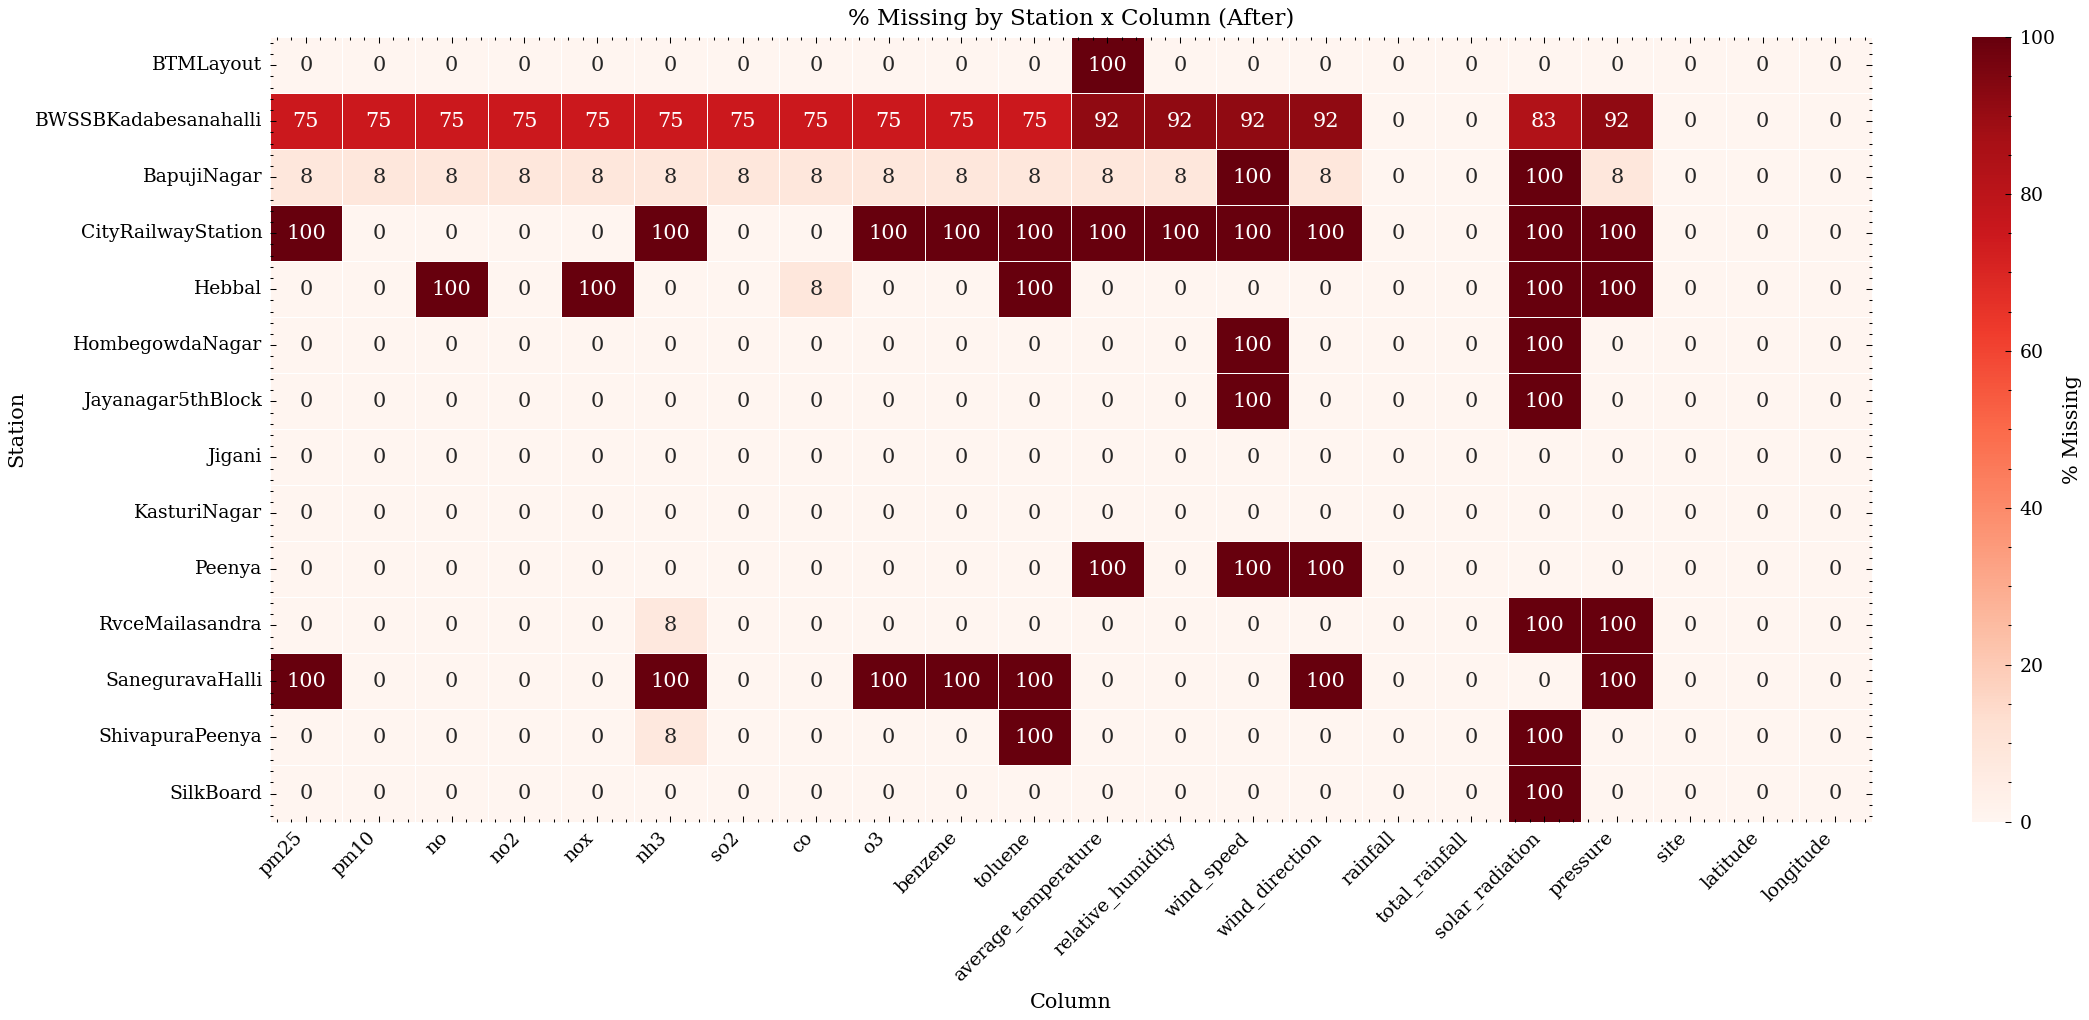

In [36]:
display(final_df.isnull().sum())
plot_missing_heatmap(
    final_df, "% Missing by Station x Column (After)", "03_heatmap_of_missing_values_after_imputation.png"
)

In [37]:
# ─────────────────────────────────────────────────────────────────────────────
# BLOCK 8 — IMPUTATION LOG ANALYSIS
# What: Turn the log list into a DataFrame and print a clear summary.
# Why:  Helps you understand HOW each gap was filled (trust the numbers).
# ─────────────────────────────────────────────────────────────────────────────

log_df = pd.DataFrame(imputation_log)
print("Imputation log — total fills by method:")
print(
    log_df.groupby("method")["n_filled"].sum().sort_values(ascending=False).to_string()
)
print("Imputation log — total fills by column (top 15):")
print(log_df.groupby("col")["n_filled"].sum().nlargest(15).to_string())


Imputation log — total fills by method:
method
ffill                679358
prev_day             419428
linear_interp        327152
month_hour_median     78287
circular_interp       71104
rolling_1h_median     14984
col_median             2400
Imputation log — total fills by column (top 15):
col
rainfall             363998
total_rainfall       315360
co                    77871
pm10                  72372
wind_direction        71104
so2                   69298
no                    67272
no2                   64032
pm25                  58142
nox                   57784
nh3                   55695
relative_humidity     54465
benzene               49265
o3                    43711
wind_speed            42319


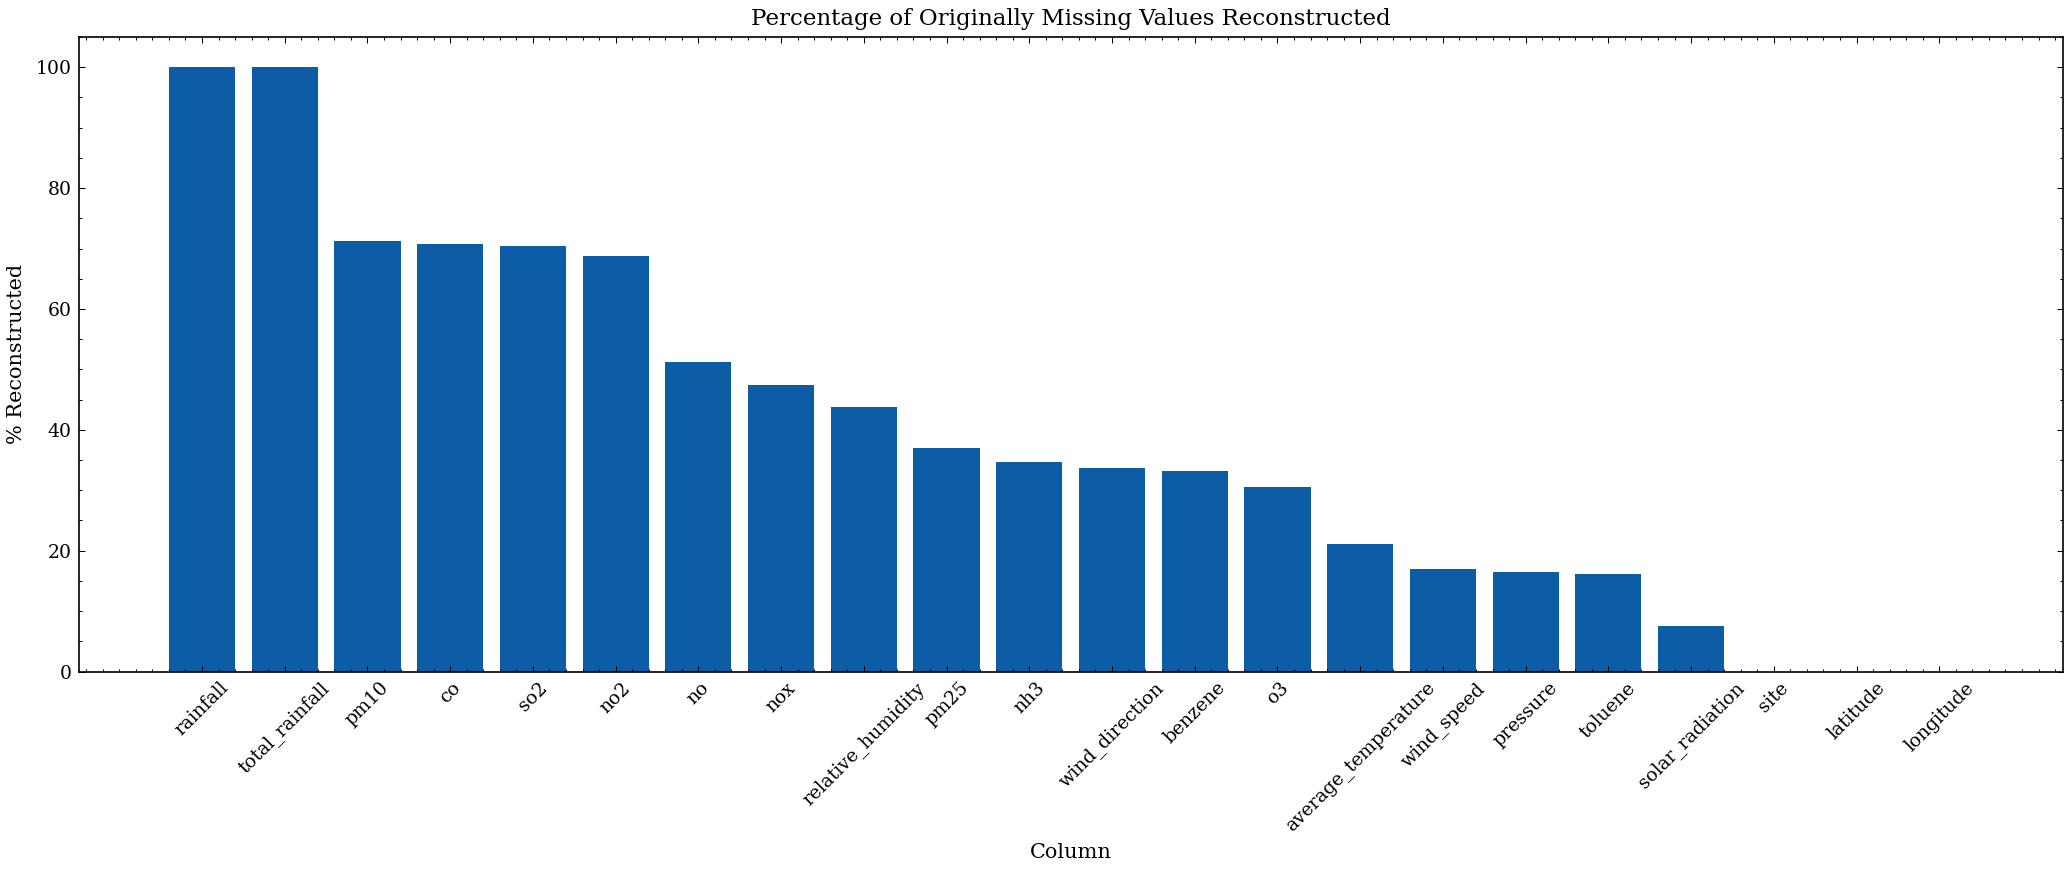

Saved → /home/srirama/Documents/sr_proj/AirModeling/backend/data/artifacts/plots/04_reconstructed_percentage.png


In [38]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

numeric_cols = master_df.select_dtypes(include=np.number).columns

before_missing = master_df[numeric_cols].isna().sum()
after_missing = final_df[numeric_cols].isna().sum()

reconstructed = before_missing - after_missing
reconstructed_pct = (reconstructed / before_missing.replace(0, np.nan)) * 100
reconstructed_pct = (
    reconstructed_pct.replace([np.inf, -np.inf], np.nan)
    .fillna(0)
    .sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(reconstructed_pct.index, reconstructed_pct.values)

ax.set_title("Percentage of Originally Missing Values Reconstructed")
ax.set_ylabel("% Reconstructed")
ax.set_xlabel("Column")
ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
path = PLOTS_DIR / "04_reconstructed_percentage.png"
fig.savefig(path, dpi=300)
plt.show()
print(f"Saved → {path}")

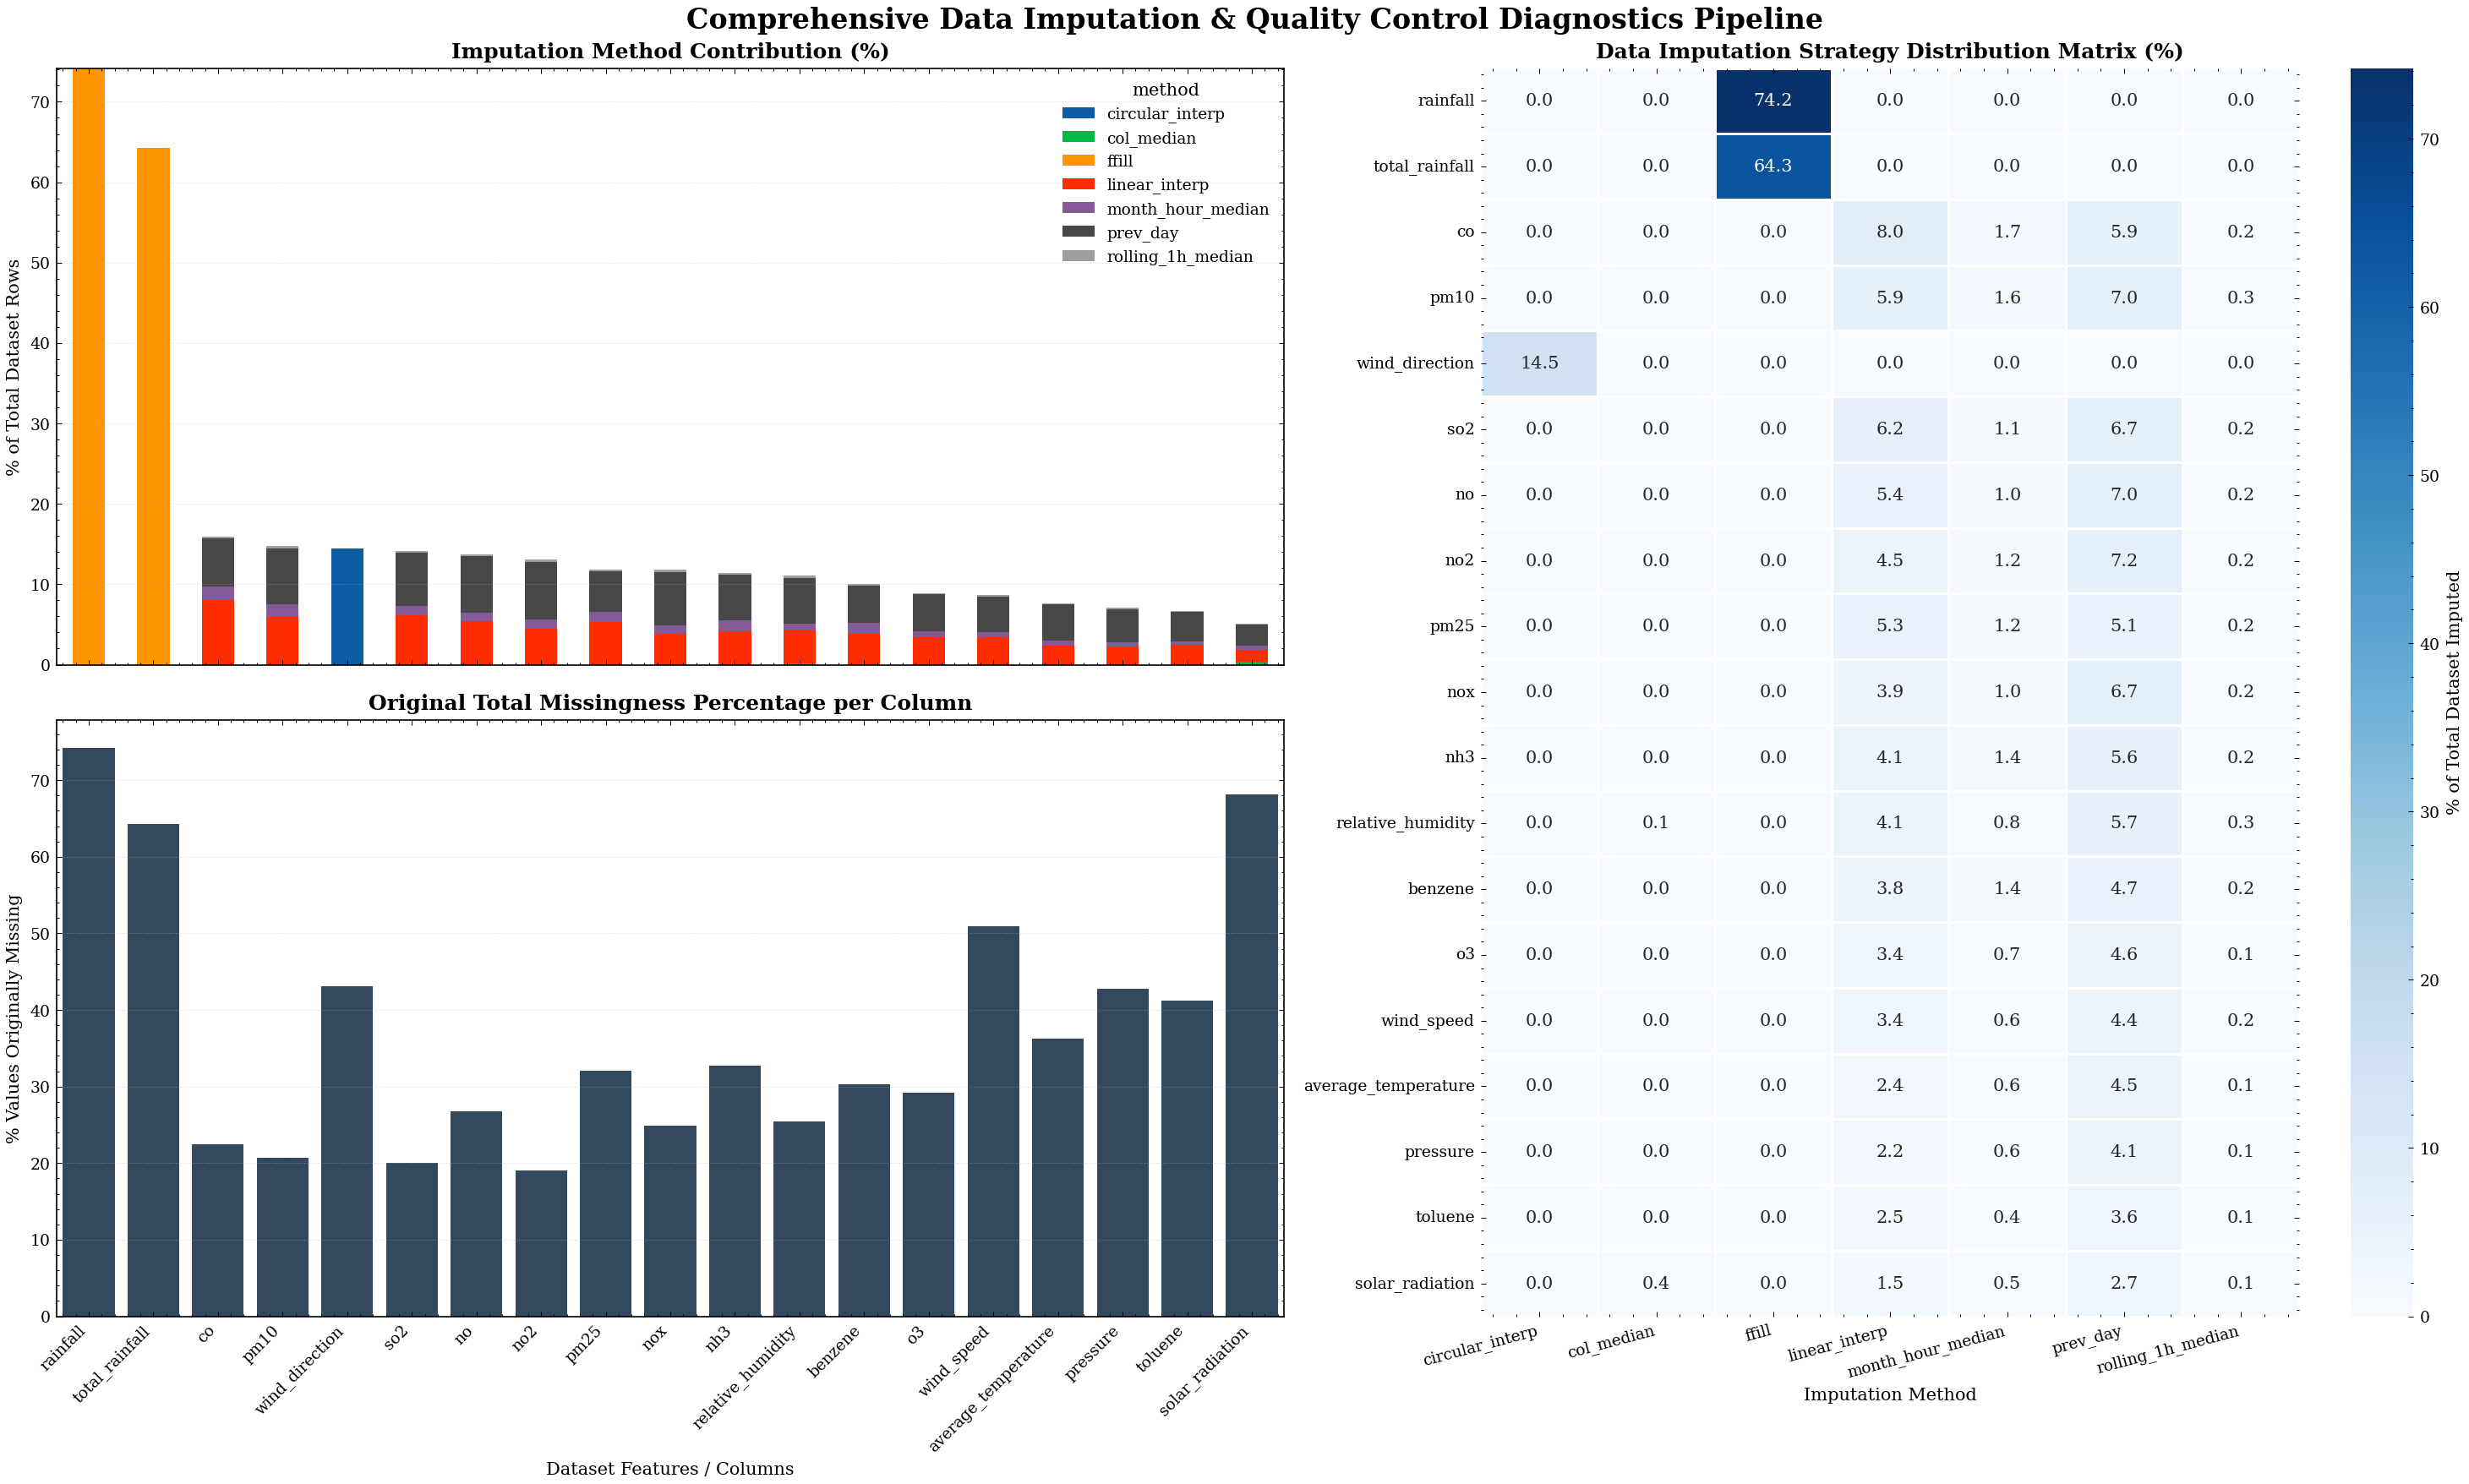

Saved Unified Diagnostic Plot → /home/srirama/Documents/sr_proj/AirModeling/backend/data/artifacts/plots/unified_imputation_diagnostic_report.png


In [39]:
# ─────────────────────────────────────────────────────────────
# BLOCK 10 — ADVANCED IMPUTATION VISUALIZATION
# ─────────────────────────────────────────────────────────────
import matplotlib.gridspec as gridspec

# Create the dataframes from your logs
log_df = pd.DataFrame(imputation_log)
original_missing = master_df.isna().sum()

# 1. Calculate & Normalize Data to Percentages
# Raw counts matrix
raw_counts = log_df.groupby(["col", "method"])["n_filled"].sum().unstack(fill_value=0)

# Convert both metrics to true percentage of the entire dataset size
method_col_pct = (raw_counts / len(master_df)) * 100
reconstructed_pct = (original_missing / len(master_df)) * 100

# Sort everything by total missingness so both left charts line up perfectly
sorted_cols = method_col_pct.sum(axis=1).sort_values(ascending=False).index
method_col_pct = method_col_pct.loc[sorted_cols]
reconstructed_pct = reconstructed_pct.loc[sorted_cols]

# 2. Setup the Unified Figure Layout
fig = plt.figure(figsize=(20, 12))
gs = gridspec.GridSpec(2, 2, width_ratios=[1.2, 1], height_ratios=[1, 1])

ax1 = fig.add_subplot(gs[0, 0])  # Top Left: Stacked Bar (Now %!)
ax2 = fig.add_subplot(gs[1, 0], sharex=ax1)  # Bottom Left: Total Missing Pct
ax3 = fig.add_subplot(gs[:, 1])  # Right Side: Heatmap Matrix

# =============================================================================
# CHART 1: Imputation Contribution Percentage per Column (Top Left)
# =============================================================================
method_col_pct.plot(kind="bar", stacked=True, ax=ax1, legend=True)
ax1.set_title("Imputation Method Contribution (%)", fontsize=12, weight="bold")
ax1.set_ylabel("% of Total Dataset Rows")
ax1.set_xlabel("")
ax1.grid(axis="y", linestyle=":", alpha=0.5)

# =============================================================================
# CHART 2: Percentage of Column Reconstructed (Bottom Left)
# =============================================================================
ax2.bar(reconstructed_pct.index, reconstructed_pct.values, color="#34495e")
ax2.set_title(
    "Original Total Missingness Percentage per Column", fontsize=12, weight="bold"
)
ax2.set_ylabel("% Values Originally Missing")
ax2.set_xlabel("Dataset Features / Columns")
ax2.set_xticklabels(reconstructed_pct.index, rotation=45, ha="right")
ax2.grid(axis="y", linestyle=":", alpha=0.5)

# =============================================================================
# CHART 3: Academic Heatmap (Right Side - Full Height)
# =============================================================================
sns.heatmap(
    method_col_pct,  # Shares the exact same percentage matrix data
    annot=True,
    fmt=".1f",
    cmap="Blues",
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"label": "% of Total Dataset Imputed"},
    ax=ax3,
)
ax3.set_title(
    "Data Imputation Strategy Distribution Matrix (%)", fontsize=12, weight="bold"
)
ax3.set_xlabel("Imputation Method")
ax3.set_ylabel("")
ax3.set_xticklabels(ax3.get_xticklabels(), rotation=15, ha="right")

# Final Save & Presentation
plt.suptitle(
    "Comprehensive Data Imputation & Quality Control Diagnostics Pipeline",
    fontsize=16,
    weight="bold",
    y=0.98,
)
plt.tight_layout()

path = PLOTS_DIR / "unified_imputation_diagnostic_report.png"
plt.savefig(path, dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved Unified Diagnostic Plot → {path}")

## Every station distribution fro each feature - dont run since images already saved

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from pathlib import Path

DIST_DIR = PLOTS_DIR / "station_distributions"
DIST_DIR.mkdir(exist_ok=True)

# Numeric columns only
numeric_cols = master_df.select_dtypes(include=np.number).columns.tolist()

# Optional: remove identifiers
exclude_cols = ["site", "latitude", "longitude"]
numeric_cols = [c for c in numeric_cols if c not in exclude_cols]

stations = sorted(master_df["station_name"].dropna().unique())

for station in stations:
    print(f"\nPlotting distributions for: {station}")
    before_df = master_df[master_df["station_name"] == station]
    after_df = final_df[final_df["station_name"] == station]
    n_cols = 2
    n_rows = int(np.ceil(len(numeric_cols) / n_cols))
    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(14, 4 * n_rows),
    )
    axes = np.array(axes).flatten()
    for i, col in enumerate(numeric_cols):
        ax = axes[i]

        before_vals = before_df[col].dropna()
        after_vals = after_df[col].dropna()

        # Skip completely empty columns
        if len(before_vals) == 0 and len(after_vals) == 0:
            ax.set_visible(False)
            continue

        # BEFORE
        if len(before_vals) > 0:
            sns.kdeplot(
                before_vals,
                ax=ax,
                label="Before",
                linewidth=2,
            )

        # AFTER
        if len(after_vals) > 0:
            sns.kdeplot(
                after_vals,
                ax=ax,
                label="After",
                linewidth=2,
                linestyle="--",
            )

        ax.set_title(col)
        ax.legend()

    # Hide unused axes
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)
    fig.suptitle(
        f"Distribution Comparison — {station}",
        fontsize=18,
    )
    plt.tight_layout(rect=[0, 0, 1, 0.98])
    save_path = DIST_DIR / f"{station}_distribution_compare.png"
    fig.savefig(save_path, dpi=300)
    plt.close(fig)
    print(f"Saved → {save_path}")

In [40]:
# ─────────────────────────────────────────────────────────────────────────────
# BLOCK 12 — COMBINE & SAVE
# What: Stack all per-station DataFrames back into one master DataFrame.
# Why:  Downstream modelling expects a single CSV.
# ─────────────────────────────────────────────────────────────────────────────

final_df.to_csv(IMPUTED_PATH, index=False)

print(f"Block 7 — Saved imputed dataset → {IMPUTED_PATH}")
print(f"Original rows : {len(master_df):,}")
print(f"Imputed  rows : {len(final_df):,}  (extra rows = timestamps filled by asfreq)")

Block 7 — Saved imputed dataset → /home/srirama/Documents/sr_proj/AirModeling/backend/data/artifacts/final_master_dataset.csv
Original rows : 490,560
Imputed  rows : 490,560  (extra rows = timestamps filled by asfreq)
